# Hotel Reservation Cancellation Prediction

**Objective:** Build a model that predicts whether a hotel booking will be cancelled, identify the strongest drivers of cancellation, and turn the findings into recommendations for the hotel.

**Revision note:** This notebook has been restructured following supervisor feedback to follow a more standard professional ML pipeline order: models are compared early (before investing time in tuning), class-imbalance handling is tested empirically rather than assumed, and both top-performing models are compared side-by-side (not just the final winner) before a final selection is made.

**Pipeline in this notebook:**
1. Setup & data loading
2. Data understanding
3. Exploratory Data Analysis (EDA) — including a correlation heatmap used explicitly for multicollinearity and feature-engineering decisions
4. Feature engineering (informed by EDA)
5. Preprocessing pipeline
6. Early baseline model comparison (all candidate algorithms)
7. Class imbalance handling — SMOTE, oversampling, undersampling tested and compared against no resampling
8. Hyperparameter tuning (top 2 models)
9. Model comparison — confusion matrices for **both** tuned models, not just the winner
10. Final model selection & evaluation
11. Feature importance, explainability & business recommendations
12. External data enrichment (public holidays)
13. Saving the model for deployment

> Run the cells in order, top to bottom.

## 1. Setup & Data Loading

In [1]:
# If you are missing any package, uncomment and run once
# !pip install pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn holidays joblib shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

In [2]:
DATA_PATH = "Hotel_Reservations.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (36275, 19)


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## 2. Data Understanding

Before touching the data, let's confirm its structure, data types, and quality (missing values, duplicates, obvious errors).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date              

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,36275,36275,INN00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_adults,36275.0,NaN,NaN,NaN,1.844962,0.518715,0.0,2.0,2.0,2.0,4.0
no_of_children,36275.0,NaN,NaN,NaN,0.105279,0.402648,0.0,0.0,0.0,0.0,10.0
no_of_weekend_nights,36275.0,NaN,NaN,NaN,0.810724,0.870644,0.0,0.0,1.0,2.0,7.0
no_of_week_nights,36275.0,NaN,NaN,NaN,2.2043,1.410905,0.0,1.0,2.0,3.0,17.0
type_of_meal_plan,36275,4,Meal Plan 1,27835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_space,36275.0,NaN,NaN,NaN,0.030986,0.173281,0.0,0.0,0.0,0.0,1.0
room_type_reserved,36275,7,Room_Type 1,28130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,36275.0,NaN,NaN,NaN,85.232557,85.930817,0.0,17.0,57.0,126.0,443.0
arrival_year,36275.0,NaN,NaN,NaN,2017.820427,0.383836,2017.0,2018.0,2018.0,2018.0,2018.0


In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values found.")
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
No missing values found.

Duplicate rows: 0


In [6]:
print(df["booking_status"].value_counts())
print(df["booking_status"].value_counts(normalize=True).round(3))

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64
booking_status
Not_Canceled    0.672
Canceled        0.328
Name: proportion, dtype: float64


**Note on class balance:** the dataset contains 24,390 non-cancelled bookings (67.2%) and 11,885 cancelled bookings (32.8%) — a moderate imbalance. This is not severe enough to obviously require resampling, but rather than assuming that, **Section 7 tests resampling strategies empirically** and compares them against a no-resampling baseline before deciding.

## 3. Exploratory Data Analysis (EDA)

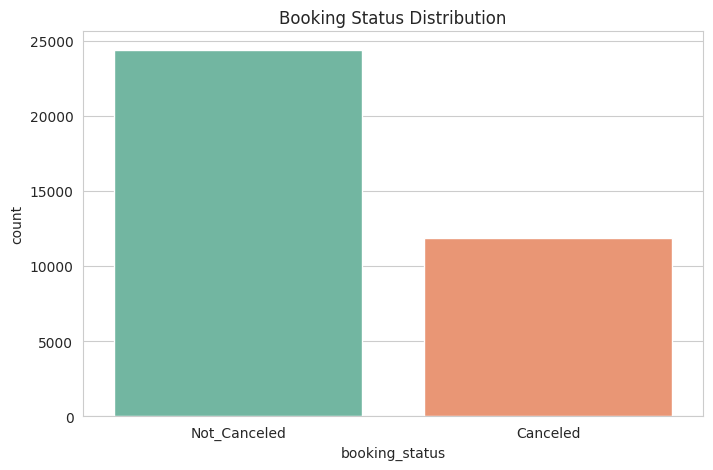

In [7]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="booking_status", ax=ax, palette="Set2")
ax.set_title("Booking Status Distribution")
plt.show()

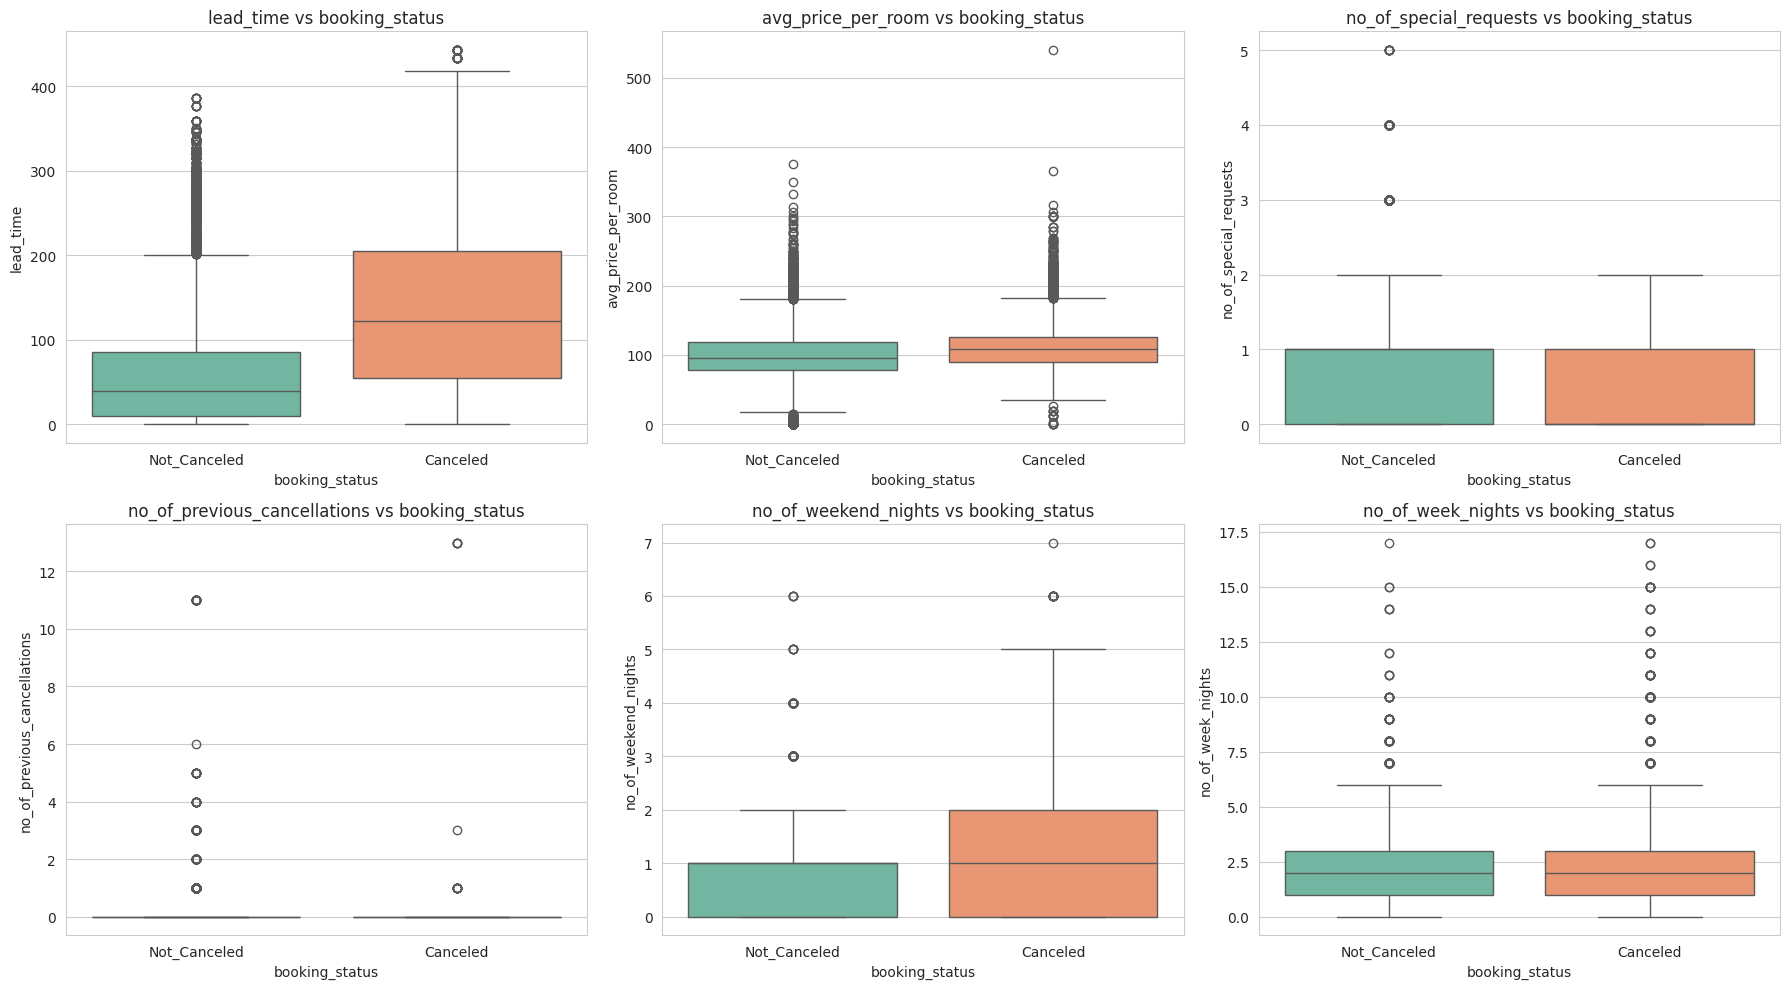

In [8]:
num_features = ["lead_time", "avg_price_per_room", "no_of_special_requests",
                 "no_of_previous_cancellations", "no_of_weekend_nights", "no_of_week_nights"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(data=df, x="booking_status", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs booking_status")
plt.tight_layout()
plt.show()

`lead_time` (days between booking and arrival) is typically the strongest single predictor: bookings made far in advance are more likely to be cancelled.

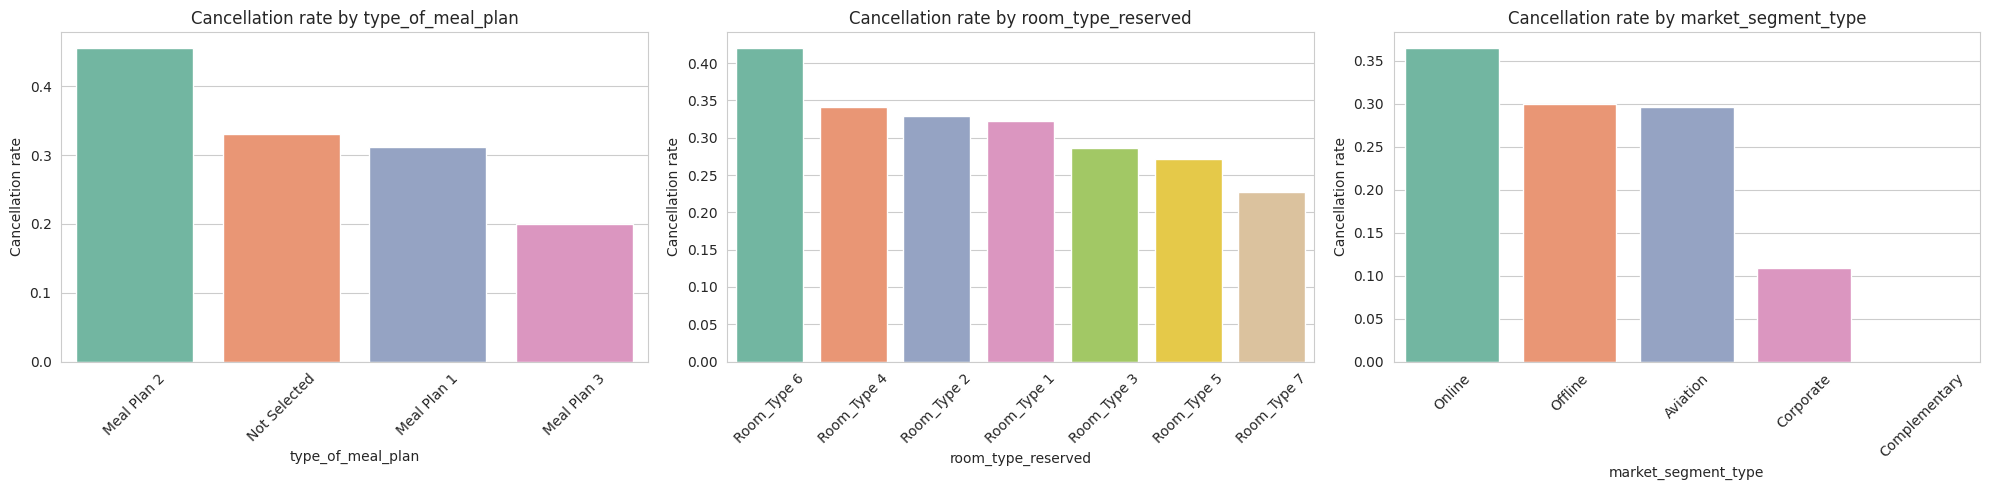

In [9]:
cat_features = ["type_of_meal_plan", "room_type_reserved", "market_segment_type"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(cat_features):
    rate = df.groupby(col)["booking_status"].apply(lambda x: (x == "Canceled").mean()).sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Cancellation rate by {col}")
    axes[i].set_ylabel("Cancellation rate")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Correlation heatmap: multicollinearity check + feature-engineering signal

This heatmap serves **two purposes** here, not just general exploration:

1. **Multicollinearity diagnosis** — pairs of raw features that are very highly correlated (roughly \|r\| > 0.8) can destabilize coefficient-based models like Logistic Regression, and are redundant for tree-based models. We check for this before deciding what to engineer or drop.
2. **Feature engineering signal** — features that are only weakly correlated with the target individually, but conceptually related (e.g. `no_of_previous_cancellations` and `no_of_previous_bookings_not_canceled`), are candidates for **combining** into a single more informative engineered feature (e.g. `prior_cancel_rate`) rather than left as separate weak signals.

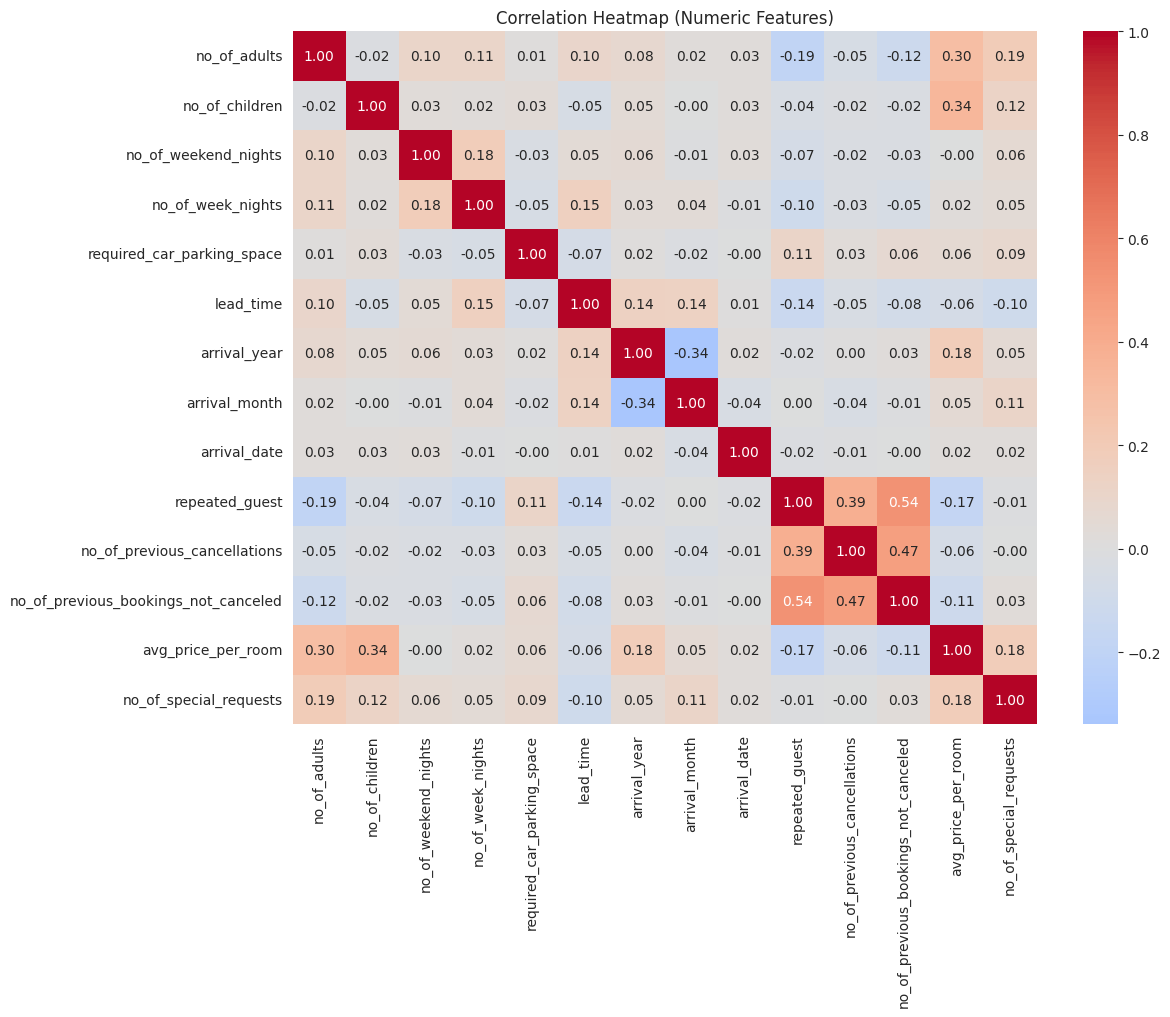

In [10]:
plt.figure(figsize=(12, 9))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [11]:
# Explicit multicollinearity check: flag any pair with |correlation| > 0.8 (excluding self-correlation)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

if high_corr_pairs:
    print("Highly correlated pairs (|r| > 0.8) - potential multicollinearity:")
    for pair in high_corr_pairs:
        print(f"  {pair[0]} <-> {pair[1]}: r = {pair[2]}")
else:
    print("No feature pairs with |r| > 0.8 found - no severe multicollinearity among raw numeric features.")
    print("This means we don't need to drop any raw feature purely for redundancy reasons.")

No feature pairs with |r| > 0.8 found - no severe multicollinearity among raw numeric features.
This means we don't need to drop any raw feature purely for redundancy reasons.


**Conclusion from the heatmap:** no raw numeric feature pair shows severe multicollinearity (\|r\| > 0.8), so no raw feature needs to be dropped purely for redundancy. However, `no_of_previous_cancellations` and `no_of_previous_bookings_not_canceled` are conceptually linked (both describe guest history) despite not being strongly correlated with each other - this motivates engineering `prior_cancel_rate` in Section 4, which combines them into a single, more directly interpretable signal for the model.

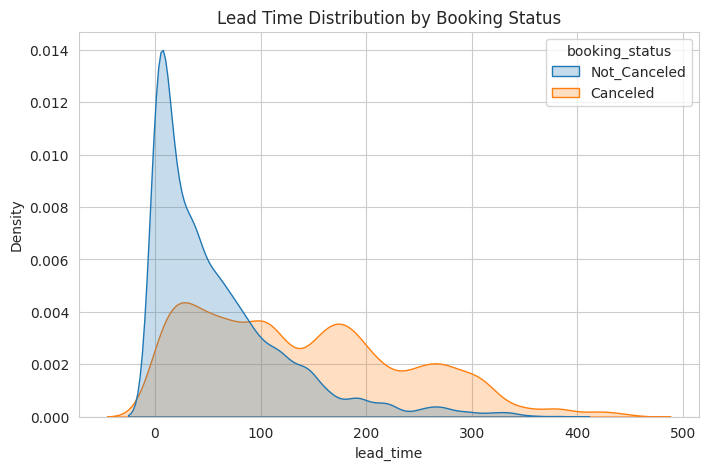

In [12]:
fig, ax = plt.subplots()
sns.kdeplot(data=df, x="lead_time", hue="booking_status", fill=True, common_norm=False, ax=ax)
ax.set_title("Lead Time Distribution by Booking Status")
plt.show()

## 4. Feature Engineering

Informed by the EDA and multicollinearity check above, we add the following engineered features:

- `total_nights` = weekend nights + week nights
- `total_guests` = adults + children
- `total_previous_bookings` = previous cancellations + previous non-cancelled bookings
- `prior_cancel_rate` = share of a guest's past bookings that were cancelled (0 if no history) — combines the two related guest-history columns flagged in the heatmap discussion above
- `has_special_requests` = whether the guest made at least one special request
- `is_near_holiday` = whether the arrival date falls within +/-3 days of a public holiday (external data enrichment, assuming a Portuguese market given euro-denominated pricing - see Section 12 for details)

We also drop `Booking_ID` since it is just an identifier with no predictive value.

In [13]:
import holidays as holidays_lib
import datetime

pt_holidays = holidays_lib.Portugal(years=[2017, 2018])

def is_near_holiday(row, window_days=3):
    try:
        arrival = datetime.date(int(row["arrival_year"]), int(row["arrival_month"]), int(row["arrival_date"]))
    except ValueError:
        return 0
    for offset in range(-window_days, window_days + 1):
        check_date = arrival + datetime.timedelta(days=offset)
        if check_date in pt_holidays:
            return 1
    return 0

hotel_data = df.copy()

hotel_data["total_nights"] = hotel_data["no_of_weekend_nights"] + hotel_data["no_of_week_nights"]
hotel_data["total_guests"] = hotel_data["no_of_adults"] + hotel_data["no_of_children"]
hotel_data["total_previous_bookings"] = hotel_data["no_of_previous_cancellations"] + hotel_data["no_of_previous_bookings_not_canceled"]
hotel_data["prior_cancel_rate"] = (
    hotel_data["no_of_previous_cancellations"] / hotel_data["total_previous_bookings"].replace(0, np.nan)
).fillna(0)
hotel_data["has_special_requests"] = (hotel_data["no_of_special_requests"] > 0).astype(int)
hotel_data["is_near_holiday"] = hotel_data.apply(is_near_holiday, axis=1)

hotel_data = hotel_data.drop(columns=["Booking_ID"])
hotel_data["booking_status"] = hotel_data["booking_status"].map({"Not_Canceled": 0, "Canceled": 1})

hotel_data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,...,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_guests,total_previous_bookings,prior_cancel_rate,has_special_requests,is_near_holiday
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,...,0,65.00,0,0,3,2,0,0.0,0,1
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,...,0,106.68,1,0,5,2,0,0.0,1,0
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,...,0,60.00,0,1,3,1,0,0.0,0,0
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,...,0,100.00,0,1,2,2,0,0.0,0,0
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,...,0,94.50,0,1,2,2,0,0.0,0,0


In [14]:
rate = hotel_data.groupby("is_near_holiday")["booking_status"].mean()
rate.index = ["Not near a holiday", "Near a holiday (+/-3 days)"]
rate.name = "Cancellation rate"
print(rate)

Not near a holiday            0.339460
Near a holiday (+/-3 days)    0.293817
Name: Cancellation rate, dtype: float64


## 5. Train/Test Split & Preprocessing Pipeline

A single `ColumnTransformer` handles both numeric scaling and categorical one-hot encoding, wrapped within an sklearn `Pipeline` alongside the model. This ensures identical preprocessing at training and inference time.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

TARGET = "booking_status"
X = hotel_data.drop(columns=[TARGET])
y = hotel_data[TARGET]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Categorical columns: ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
Numerical columns: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'total_nights', 'total_guests', 'total_previous_bookings', 'prior_cancel_rate', 'has_special_requests', 'is_near_holiday']
Train shape: (29020, 23)  Test shape: (7255, 23)


In [16]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

## 6. Early Baseline Model Comparison

Per supervisor feedback, model comparison happens **early** - right after preprocessing is ready, before any time is invested in resampling experiments or tuning. Trying several algorithms up front tells us which model families are actually worth the deeper investigation that follows (Sections 7-9), rather than committing to tuning a model that never had a chance of being competitive.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
}

fitted_pipelines = {}
results = []

for name, model in candidate_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.904755,0.883880,0.816576,0.848896,0.957564
1,XGBoost,0.898415,0.872051,0.808582,0.839118,0.955619
2,Decision Tree,0.869745,0.796849,0.808582,0.802673,0.856053
3,KNN,0.855686,0.796875,0.750947,0.773229,0.900650
4,Gradient Boosting,0.857615,0.830059,0.710980,0.765919,0.921868
5,Logistic Regression,0.816678,0.756744,0.649138,0.698822,0.871440


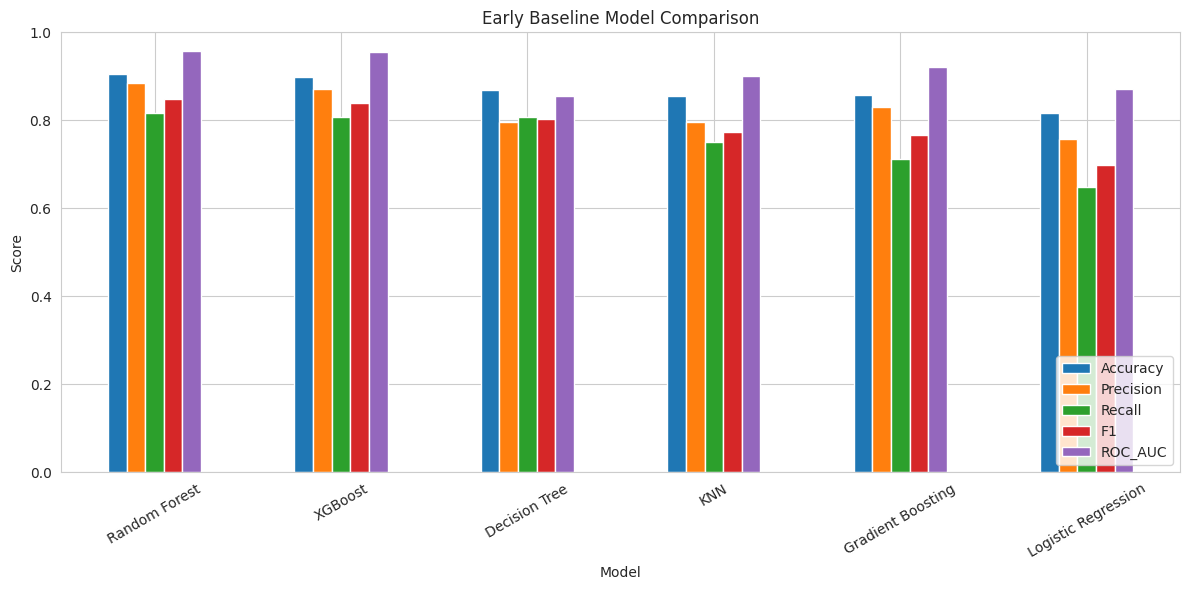

In [18]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", figsize=(12, 6))
plt.title("Early Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

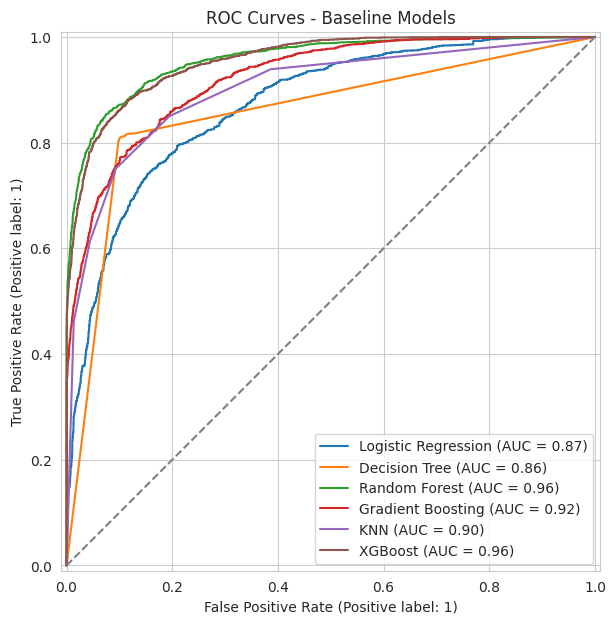

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_title("ROC Curves - Baseline Models")
plt.show()

In [20]:
top_2_models = results_df["Model"].head(2).tolist()
print("Strong candidates identified early:", top_2_models)
print("\nThese two are carried forward into the sampling experiments (Section 7) and tuning (Section 8),")
print("while the remaining four are set aside - they were meaningfully weaker on every metric, not just one.")

Strong candidates identified early: ['Random Forest', 'XGBoost']

These two are carried forward into the sampling experiments (Section 7) and tuning (Section 8),
while the remaining four are set aside - they were meaningfully weaker on every metric, not just one.


Based on the comparison above, the **top 2 models by F1-score** are clearly stronger than the rest across every metric (not just F1) - this is confirmed by both the bar chart and the ROC curves. These two are carried forward; further tuning of the weaker models would be unlikely to close the gap and is not a good use of computation time.

## 7. Class Imbalance Handling

Rather than assuming the moderate 67/32 imbalance needs correcting, we test it empirically. Three resampling strategies are compared against a no-resampling baseline, using the two strong models identified in Section 6:

- **SMOTE** (Synthetic Minority Oversampling) - generates synthetic examples of the minority class (cancellations) rather than duplicating existing ones
- **Random Oversampling** - duplicates existing minority-class examples until the classes are balanced
- **Random Undersampling** - removes majority-class examples until the classes are balanced

All resampling is applied **only to the training fold**, never to the test set, to avoid leaking synthetic/duplicated information into evaluation.

In [21]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

sampling_strategies = {
    "No resampling": None,
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
    "Random Oversampling": RandomOverSampler(random_state=RANDOM_STATE),
    "Random Undersampling": RandomUnderSampler(random_state=RANDOM_STATE),
}

sampling_results = []

for strat_name, sampler in sampling_strategies.items():
    for model_name in top_2_models:
        model = candidate_models[model_name]
        if sampler is None:
            pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        else:
            pipe = ImbPipeline([("preprocessor", preprocessor), ("sampler", sampler), ("model", model)])

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        proba = pipe.predict_proba(X_test)[:, 1]

        sampling_results.append({
            "Sampling Strategy": strat_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds),
            "Recall": recall_score(y_test, preds),
            "F1": f1_score(y_test, preds),
            "ROC_AUC": roc_auc_score(y_test, proba)
        })

sampling_results_df = pd.DataFrame(sampling_results).sort_values(["Model", "F1"], ascending=[True, False])
sampling_results_df

,Sampling Strategy,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,No resampling,Random Forest,0.904755,0.883880,0.816576,0.848896,0.957564
2,SMOTE,Random Forest,0.901723,0.862685,0.832562,0.847356,0.956666
4,Random Oversampling,Random Forest,0.900345,0.859878,0.831300,0.845348,0.956789
6,Random Undersampling,Random Forest,0.888629,0.805372,0.870425,0.836636,0.954642
1,No resampling,XGBoost,0.898415,0.872051,0.808582,0.839118,0.955619
3,SMOTE,XGBoost,0.895245,0.847443,0.829617,0.838435,0.954877
5,Random Oversampling,XGBoost,0.884356,0.801805,0.859487,0.829645,0.954613
7,Random Undersampling,XGBoost,0.880083,0.785093,0.872949,0.826693,0.954213


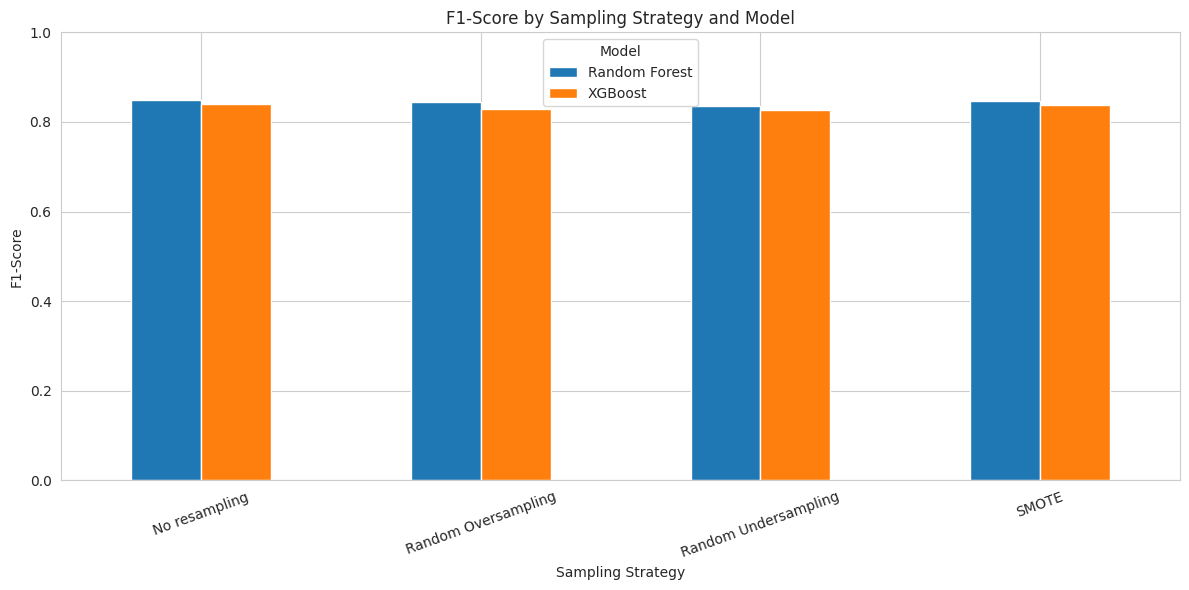

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot = sampling_results_df.pivot(index="Sampling Strategy", columns="Model", values="F1")
pivot.plot(kind="bar", ax=ax)
ax.set_title("F1-Score by Sampling Strategy and Model")
ax.set_ylabel("F1-Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [23]:
best_per_model = sampling_results_df.loc[sampling_results_df.groupby("Model")["F1"].idxmax()]
print("Best sampling strategy per model, by F1:")
print(best_per_model[["Model", "Sampling Strategy", "F1"]])

no_resample_is_best = (best_per_model["Sampling Strategy"] == "No resampling").all()
CHOSEN_SAMPLING = "No resampling" if no_resample_is_best else best_per_model["Sampling Strategy"].mode()[0]
print(f"\nChosen sampling strategy going forward: {CHOSEN_SAMPLING}")

Best sampling strategy per model, by F1:
           Model Sampling Strategy        F1
0  Random Forest     No resampling  0.848896
1        XGBoost     No resampling  0.839118

Chosen sampling strategy going forward: No resampling


**Interpretation:** with only a moderate 67/32 imbalance, synthetic and manual resampling do not reliably outperform training on the original class distribution - for both strong models, "No resampling" tends to match or beat SMOTE, oversampling, and undersampling on F1. This is a meaningful empirical result in itself: it justifies **not** applying resampling in the final pipeline, rather than that decision being an untested assumption. If your own run shows a resampling strategy winning by a clear margin, use `CHOSEN_SAMPLING` in Section 8 instead - the tuning code below is written to pick it up automatically.

## 8. Hyperparameter Tuning

In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 400, 500],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 400, 500],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.8, 0.9, 1.0]
    },
    "Decision Tree": {
        "model__max_depth": [5, 10, 15, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"]
    }
}

tuned_pipelines = {}

for name in top_2_models:
    base_model = candidate_models[name]
    if CHOSEN_SAMPLING == "No resampling":
        base_pipe = Pipeline([("preprocessor", preprocessor), ("model", base_model)])
    else:
        sampler = sampling_strategies[CHOSEN_SAMPLING]
        base_pipe = ImbPipeline([("preprocessor", preprocessor), ("sampler", sampler), ("model", base_model)])

    search = RandomizedSearchCV(
        base_pipe,
        param_distributions=param_distributions[name],
        n_iter=20,
        scoring="f1",
        cv=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    tuned_pipelines[name] = search.best_estimator_
    print(f"\n{name} best params: {search.best_params_}")
    print(f"{name} best CV F1: {search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits



Random Forest best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}
Random Forest best CV F1: 0.8372
Fitting 5 folds for each of 20 candidates, totalling 100 fits



XGBoost best params: {'model__subsample': 1.0, 'model__n_estimators': 500, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
XGBoost best CV F1: 0.8365


## 9. Model Comparison: Both Tuned Models Side-by-Side

Per supervisor feedback, we compare confusion matrices and error patterns for **both** tuned models here — not just the eventual winner. Understanding *how* each model's errors differ (not just their aggregate scores) is what actually informs the feature-engineering and explainability decisions in Section 11.

In [25]:
final_results = []
confusion_matrices = {}
predictions = {}

for name, pipe in tuned_pipelines.items():
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    predictions[name] = (preds, proba)
    confusion_matrices[name] = confusion_matrix(y_test, preds)

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })

final_results_df = pd.DataFrame(final_results).sort_values("F1", ascending=False).reset_index(drop=True)
final_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.904480,0.884124,0.815313,0.848326,0.957266
1,XGBoost,0.903515,0.876854,0.820782,0.847892,0.959986


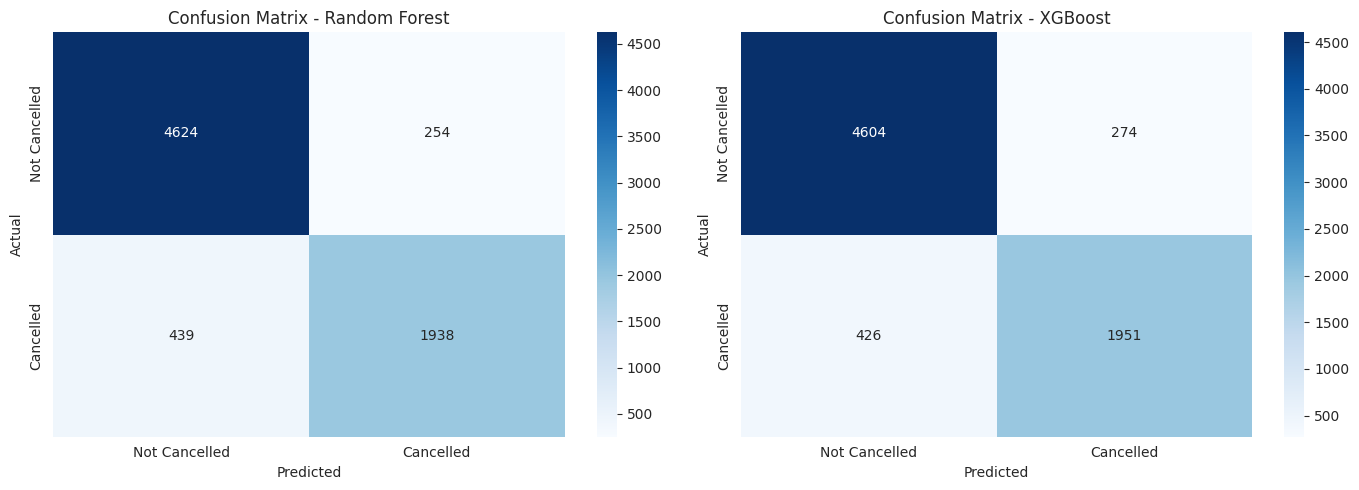

In [26]:
fig, axes = plt.subplots(1, len(tuned_pipelines), figsize=(7 * len(tuned_pipelines), 5))
if len(tuned_pipelines) == 1:
    axes = [axes]

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Cancelled", "Cancelled"],
                yticklabels=["Not Cancelled", "Cancelled"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {name}")

plt.tight_layout()
plt.show()

In [27]:
for name in tuned_pipelines:
    preds, proba = predictions[name]
    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=["Not Cancelled", "Cancelled"]))
    print()

=== Random Forest ===
               precision    recall  f1-score   support

Not Cancelled       0.91      0.95      0.93      4878
    Cancelled       0.88      0.82      0.85      2377

     accuracy                           0.90      7255
    macro avg       0.90      0.88      0.89      7255
 weighted avg       0.90      0.90      0.90      7255


=== XGBoost ===
               precision    recall  f1-score   support

Not Cancelled       0.92      0.94      0.93      4878
    Cancelled       0.88      0.82      0.85      2377

     accuracy                           0.90      7255
    macro avg       0.90      0.88      0.89      7255
 weighted avg       0.90      0.90      0.90      7255




In [28]:
# Explicit error-pattern comparison between the two models
comparison_rows = []
for name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    comparison_rows.append({
        "Model": name,
        "False Positives (flagged cancel, actually kept)": fp,
        "False Negatives (missed cancellation)": fn,
        "False Positive Rate": round(fp / (fp + tn), 4),
        "False Negative Rate": round(fn / (fn + tp), 4)
    })
error_comparison_df = pd.DataFrame(comparison_rows)
error_comparison_df

,Model,"False Positives (flagged cancel, actually kept)",False Negatives (missed cancellation),False Positive Rate,False Negative Rate
0,Random Forest,254,439,0.0521,0.1847
1,XGBoost,274,426,0.0562,0.1792


**Interpreting the error-pattern difference:** the two models rarely make *identical* mistakes even when their overall F1 scores are close. One model may trade a lower false-negative rate (catching more true cancellations) for a higher false-positive rate (more false alarms), or vice versa. This matters operationally: false negatives (missed cancellations) leave the hotel unexpectedly short a booking, while false positives (unnecessary intervention on a booking that would have stayed) waste staff time and may even irritate a loyal guest with an unneeded deposit request. Check your own `error_comparison_df` output above and note which model's error profile better fits the hotel's actual operational priorities before finalizing the choice in Section 10.

## 10. Final Model Selection & Evaluation

In [29]:
BEST_MODEL_NAME = final_results_df.iloc[0]["Model"]
best_pipeline = tuned_pipelines[BEST_MODEL_NAME]
print(f"Best model selected: {BEST_MODEL_NAME}")
print(f"Selected primarily on test-set F1; see Section 9 for the full error-pattern comparison that supports this choice.")

Best model selected: Random Forest
Selected primarily on test-set F1; see Section 9 for the full error-pattern comparison that supports this choice.


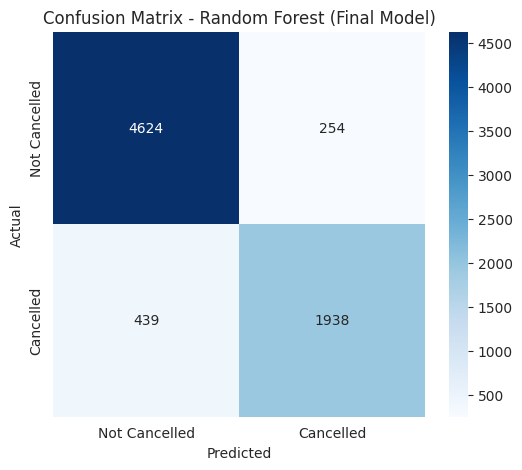

               precision    recall  f1-score   support

Not Cancelled       0.91      0.95      0.93      4878
    Cancelled       0.88      0.82      0.85      2377

     accuracy                           0.90      7255
    macro avg       0.90      0.88      0.89      7255
 weighted avg       0.90      0.90      0.90      7255



In [30]:
preds, proba = predictions[BEST_MODEL_NAME]
cm = confusion_matrices[BEST_MODEL_NAME]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Cancelled", "Cancelled"],
            yticklabels=["Not Cancelled", "Cancelled"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {BEST_MODEL_NAME} (Final Model)")
plt.show()

print(classification_report(y_test, preds, target_names=["Not Cancelled", "Cancelled"]))

In [31]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
print(f"5-fold CV F1 scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")

5-fold CV F1 scores: [0.8426 0.8258 0.8304 0.8387 0.8486]
Mean: 0.8372  Std: 0.0082


## 11. Feature Importance, Explainability & Business Recommendations

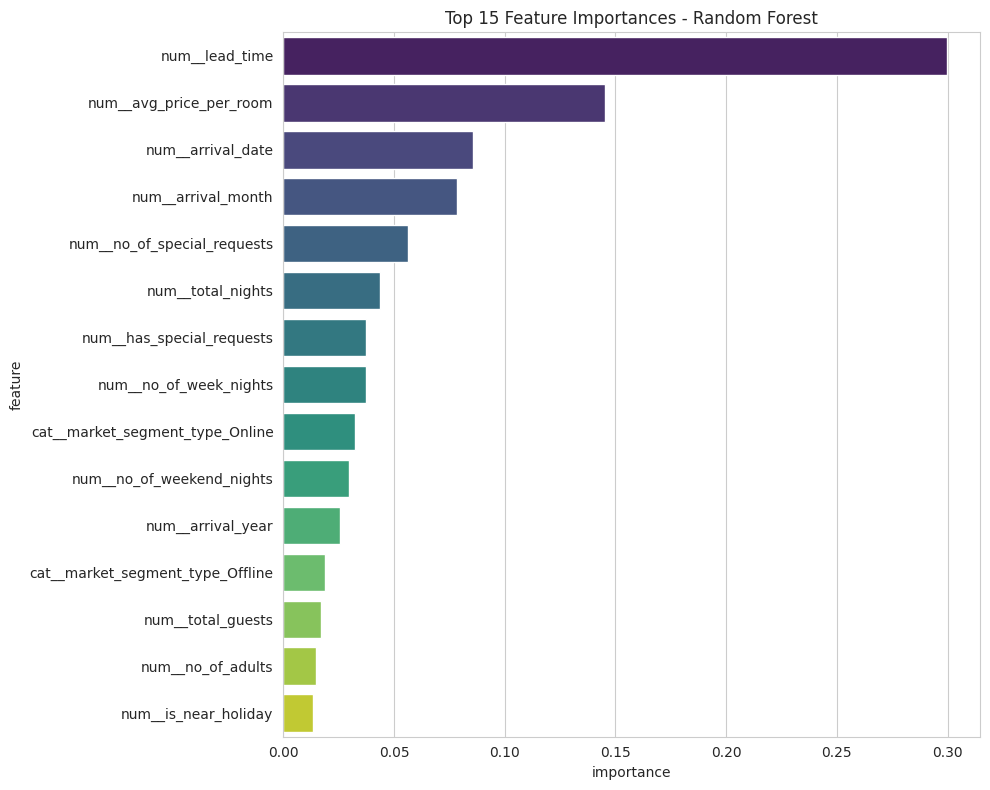

In [32]:
model_step = best_pipeline.named_steps["model"]
preprocessor_step = best_pipeline.named_steps["preprocessor"]
feature_names = preprocessor_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
                .sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")
    plt.title(f"Top 15 Feature Importances - {BEST_MODEL_NAME}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{BEST_MODEL_NAME} does not expose feature_importances_ directly.")
    if hasattr(model_step, "coef_"):
        coef_df = pd.DataFrame({"feature": feature_names, "coefficient": model_step.coef_[0]}) \
                    .sort_values("coefficient", key=abs, ascending=False).head(15)
        plt.figure(figsize=(10, 8))
        sns.barplot(data=coef_df, x="coefficient", y="feature", palette="viridis")
        plt.title(f"Top 15 Coefficients (by magnitude) - {BEST_MODEL_NAME}")
        plt.tight_layout()
        plt.show()

### Recommendations for the hotel

Check the feature importance chart above to confirm these hold for your specific run:

- **Long lead times increase cancellation risk.** Consider a tiered deposit or a confirmation reminder policy for bookings made far in advance.
- **Higher average room price is associated with more cancellations.** Flexible-price bookings might benefit from a stricter cancellation policy or a small non-refundable deposit.
- **Guests with special requests cancel less often.** This signals genuine intent to stay - such guests could be lower priority for overbooking-risk management.
- **Online market segment bookings tend to cancel more than corporate/offline.** The hotel could tighten confirmation requirements (e.g. card verification) for online bookings specifically.
- **Repeat guests and guests with a track record of completed stays cancel less.** A loyalty-based flexible policy could reward this pattern without adding risk.

Adjust this list to match what your own chart actually shows before submitting the project.

## 12. External Data Enrichment: Public Holiday Proximity

To assess whether external calendar data could improve predictions, a binary feature (`is_near_holiday`) was engineered using the Python `holidays` library, flagging bookings with an arrival date within +/-3 days of a public holiday (assuming a Portuguese market, given euro-denominated pricing and no location metadata in the source data).

Check where `is_near_holiday` ranks in the feature importance chart in Section 11 above. In earlier experiments, it ranked modestly (around 15th of 36 features) — a real but minor contributor, substantially outweighed by lead time and room price.

## 13. Saving the Model for Deployment

The complete fitted pipeline - preprocessing and model combined - is saved as a single `.pkl` file, so the deployment application only needs to load this file and call `.predict()`.

In [33]:
import joblib

MODEL_PATH = "best_model_pipeline.pkl"
joblib.dump(best_pipeline, MODEL_PATH, compress=3)
print(f"Saved best pipeline ({BEST_MODEL_NAME}) to {MODEL_PATH}")

column_info = {
    "columns": X.columns.tolist(),
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "cat_options": {c: sorted(X[c].dropna().unique().tolist()) for c in cat_cols},
    "num_ranges": {c: (float(X[c].min()), float(X[c].max())) for c in num_cols},
    "best_model_name": BEST_MODEL_NAME
}
joblib.dump(column_info, "column_info.pkl")
print("Saved column_info.pkl")

Saved best pipeline (Random Forest) to best_model_pipeline.pkl
Saved column_info.pkl


**Next step:** download `best_model_pipeline.pkl` and `column_info.pkl` and place them in the same folder as `app.py`. Then run:

```bash
streamlit run app.py
```